<a href="https://colab.research.google.com/github/cermegno/langgraph-learning/blob/main/03-nvidia-rag.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Foundation RAG pipeline with Nvidia endpoints
Graph for RAG using Nvidia endpoints and in-memory vector store.

In [1]:
!pip install langgraph langchain langchain-nvidia-ai-endpoints langchain-text-splitters langchain-core langchain-community --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 835.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [23]:
from typing import TypedDict, Annotated, List
from langgraph.graph import StateGraph, START, END
from langgraph.graph import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_core.documents import Document
from langchain_nvidia_ai_endpoints import ChatNVIDIA, NVIDIAEmbeddings
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

## Nvidia setup

In [10]:
from google.colab import userdata
apikey = userdata.get('apikey')

In [46]:
os.environ["NVIDIA_API_KEY"] = apikey

embed_model = NVIDIAEmbeddings(model="nvidia/nv-embed-v1")

llm = ChatNVIDIA(
    base_url = "https://integrate.api.nvidia.com/v1",
    #api_key = apikey, # Langchain prefers to read it from ENV
    model="meta/llama-3.1-8b-instruct"
)

prompt = ChatPromptTemplate.from_messages(
    [
        ("system", "You are a helpful assistant. Use the following context to answer the question:\n\n{context}"),
        ("placeholder", "{messages}"),
    ]
)

chain = prompt | llm

## Get data for the knowledgebase

In [6]:
import os
folder_name = "data"
os.makedirs(folder_name, exist_ok=True)
!wget -O data/notes.txt https://raw.github.com/StrategicalIT/ProjectHotdog/main/data/notes.txt

--2026-05-23 01:18:58--  https://raw.github.com/StrategicalIT/ProjectHotdog/main/data/notes.txt
Resolving raw.github.com (raw.github.com)... 185.199.110.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.github.com (raw.github.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://raw.githubusercontent.com/StrategicalIT/ProjectHotdog/main/data/notes.txt [following]
--2026-05-23 01:18:59--  https://raw.githubusercontent.com/StrategicalIT/ProjectHotdog/main/data/notes.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4490 (4.4K) [text/plain]
Saving to: ‘data/notes.txt’

data/notes.txt      100%[===================>]   4.38K  --.-KB/s    in 0s      

2026-05-23 01:18:59 (44.3 MB/s) - ‘

In [7]:
with open("/content/data/notes.txt", "r") as f:
  docs = f.read()
  f.close()

## Create the Retriever

In [16]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=400,
    chunk_overlap=50,
)

chunks = text_splitter.create_documents([docs])
print(f"Created {len(chunks)} chunks")

vectorstore = InMemoryVectorStore.from_documents(
        documents=chunks,
        embedding=embed_model,
    )
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})
retriever.invoke("where was Don Quixote born?")

Created 15 chunks


[Document(id='6fee11b8-4296-4f59-8643-c1d6785ceeca', metadata={}, page_content="However, Don Quixote's perception of reality is distorted by his obsession. He famously mistakes windmills for giants, an inn for a castle, and sheep for an army. His actions, though often well-intentioned, lead to comical and often disastrous consequences."),
 Document(id='97e8ae78-9ce3-4b49-944d-9df217bbe7bf', metadata={}, page_content='With his rusty armor, old horse Rocinante, and the peasant Sancho Panza as his loyal squire, Don Quixote sets out on a series of adventures. He seeks to revive chivalry, defend the helpless, and win the heart of his idealized lady, Dulcinea del Toboso.'),
 Document(id='d0946156-7d39-4f25-9a53-6390e1f5a630', metadata={}, page_content='Don Quixote by Miguel de Cervantes.\n-----------------------------------\nIt was published in two parts in 1605 and 1615, is a foundational work of Western literature. The novel tells the story of Alonso Quijano, a middle-aged gentleman who, o

## Create the graph

In [22]:
class State(TypedDict):
  messages: Annotated[list[BaseMessage], add_messages] # Reducer appends response to messages
  # We need an additional list attribute to store the retrieved context
  context: List[Document]

In [50]:
def call_nvidia_llm(state: State) -> State:
  """Calls Nvidia LLM and updates state"""
  # First convert the list of context chunks into a string
  context_docs = state.get("context", [])
  context_text = "\n\n".join(d.page_content for d in context_docs)

  # Pass the context to the chain along with the messages
  response = chain.invoke({"context": context_text, "messages": state['messages']})

  return {"messages": [response]}
print(call_nvidia_llm({"messages": [HumanMessage(content="What's my name and how do I feel?")], "context": [Document(page_content="my name is Tim"),Document(page_content="I am happy")]}))

{'messages': [AIMessage(content='Your name is Tim. You mentioned earlier that you are happy.', additional_kwargs={}, response_metadata={'content': 'Your name is Tim. You mentioned earlier that you are happy.', 'role': 'assistant', 'reasoning_content': None, 'token_usage': {'prompt_tokens': 68, 'completion_tokens': 14, 'total_tokens': 82, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 64}}, 'finish_reason': 'stop', 'model_name': 'meta/llama-3.1-8b-instruct'}, id='lc_run--019e52b1-3150-73e2-b991-361089e4aaaf-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 68, 'output_tokens': 14, 'total_tokens': 82}, role='assistant')]}


In [39]:
def retriever_node(state: State) -> State:
    """Retrieves chunks from knowledge base and add them to the state"""
    docs = retriever.invoke(state["messages"][-1].content)

    if not docs:
      state['context'] = ["I didn't find any information related to your query."]

    state['context'] = docs
    return state
retriever_node({"messages": [HumanMessage(content="Why rockets fly")], "context": []})

{'messages': [HumanMessage(content='Why rockets fly', additional_kwargs={}, response_metadata={})],
 'context': [Document(id='071590eb-49dd-4753-8054-15de582a3478', metadata={}, page_content="Introduction to Rocketry\n------------------------\nRockets fly based on Newton's third law of motion, which states that for every action, there is an equal and opposite reaction.\nHere's how it works:\n- Propulsion: Rockets carry their own fuel and an oxidizer. This mixture is burned in a combustion chamber, producing hot, high-pressure gas."),
  Document(id='c49a85c5-5dfc-4fba-8f12-5982b62d40a3', metadata={}, page_content="- Movement in Space: Unlike airplanes, rockets don't need air to push against. They operate on the principle of action and reaction. In the vacuum of space, the absence of air resistance actually makes rockets more efficient.\n- Overcoming Gravity: To launch from Earth, a rocket's thrust must be greater than the force of gravity pulling it down."),
  Document(id='e205cdea-6439

In [51]:
graph = StateGraph(State)
graph.add_node("retriever_node", retriever_node)
graph.add_node("call_nvidia_llm", call_nvidia_llm)
graph.add_edge(START, "retriever_node")
graph.add_edge("retriever_node", "call_nvidia_llm")
graph.add_edge("call_nvidia_llm", END)
app = graph.compile()

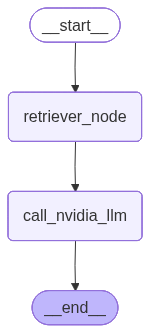

In [52]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [53]:
response = app.invoke({"messages": [HumanMessage(content="Why rockets fly")]})
print(response["messages"][-1].content)

Rockets fly based on Newton's third law of motion, which states that for every action, there is an equal and opposite reaction. This principle is the fundamental reason why rockets are able to propel themselves through space.

Here's a step-by-step explanation:

1. **Combustion**: The rocket's fuel and oxidizer are burned in a combustion chamber, producing hot, high-pressure gas.
2. **Gas expulsion**: This gas is then forced out of the rocket's nozzle at extremely high speeds.
3. **Action and reaction**: The action of the gas being expelled creates an equal and opposite reaction, pushing the rocket forward. This force is called thrust.
4. **Momentum transfer**: The momentum of the expelled gas is equal to the momentum gained by the rocket, propelling it in the opposite direction.

In essence, the rocket's motion is a result of the conservation of momentum. The expelled gas carries away momentum, which is then transferred to the rocket, propelling it forward. This is why rockets are abl

In [54]:
from pprint import pprint
pprint(response)

{'context': [Document(id='071590eb-49dd-4753-8054-15de582a3478', metadata={}, page_content="Introduction to Rocketry\n------------------------\nRockets fly based on Newton's third law of motion, which states that for every action, there is an equal and opposite reaction.\nHere's how it works:\n- Propulsion: Rockets carry their own fuel and an oxidizer. This mixture is burned in a combustion chamber, producing hot, high-pressure gas."),
             Document(id='c49a85c5-5dfc-4fba-8f12-5982b62d40a3', metadata={}, page_content="- Movement in Space: Unlike airplanes, rockets don't need air to push against. They operate on the principle of action and reaction. In the vacuum of space, the absence of air resistance actually makes rockets more efficient.\n- Overcoming Gravity: To launch from Earth, a rocket's thrust must be greater than the force of gravity pulling it down."),
             Document(id='e205cdea-6439-41d1-bf1c-41ce6901d337', metadata={}, page_content="- Thrust: This gas is for